## Imports

In [5]:
import tensorflow as tf
import numpy as np
import matplotlib
import pandas as pd
import random
import os

# Set seeds for reproducibility
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

print("Tensorflow version:", tf.__version__)
print("Numpy version:", np.__version__)
print("Matplotlib version:", matplotlib.__version__)
print("Pandas version:", pd.__version__)

# Check GPU
gpu = tf.config.list_physical_devices('GPU')
print("GPU status:", gpu)

Tensorflow version: 2.19.0
Numpy version: 2.0.2
Matplotlib version: 3.10.0
Pandas version: 2.2.2
GPU status: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


🔹 Environment Verification

Explanation:

Random seeds are set to ensure reproducibility of results.
NumPy seed controls numerical randomness.
TensorFlow seed controls model initialization and training randomness.
Python’s random seed ensures consistency in general random operations.

GPU vs CPU:

GPUs perform parallel computations, making them much faster for deep learning tasks involving matrix operations.
CPUs execute operations sequentially, which makes training slower.

In [6]:
from tensorflow.keras.datasets import mnist, cifar10

# Load datasets
(x_train_mnist, y_train_mnist), (x_test_mnist, y_test_mnist) = mnist.load_data()
(x_train_cifar, y_train_cifar), (x_test_cifar, y_test_cifar) = cifar10.load_data()

# shape of the training and test arrays
print("MNIST Train Shape:", x_train_mnist.shape)
print("MNIST Test Shape:", x_test_mnist.shape)

print("CIFAR Train Shape:", x_train_cifar.shape)
print("CIFAR Test Shape:", x_test_cifar.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 26s 0us/step
MNIST Train Shape: (60000, 28, 28)
MNIST Test Shape: (10000, 28, 28)
CIFAR Train Shape: (50000, 32, 32, 3)
CIFAR Test Shape: (10000, 32, 32, 3)


In [7]:
#data type and value range of the pixel values

# MNIST

print("MNIST datatype:", x_train_mnist.dtype)
print("MNIST range:", x_train_mnist.min(), x_train_mnist.max())

# CIFAR
print("CIFAR datatype:", x_train_cifar.dtype)
print("CIFAR range:", x_train_cifar.min(), x_train_cifar.max())

MNIST datatype: uint8
MNIST range: 0 255
CIFAR datatype: uint8
CIFAR range: 0 255


In [8]:
# samples per class

import numpy as np

print("MNIST class distribution:")
print(np.bincount(y_train_mnist))

MNIST class distribution:
[5923 6742 5958 6131 5842 5421 5918 6265 5851 5949]


🔹 Dataset Observations
MNIST images have shape (28, 28) and are grayscale.
It is balanced, with approximately equal samples per class.

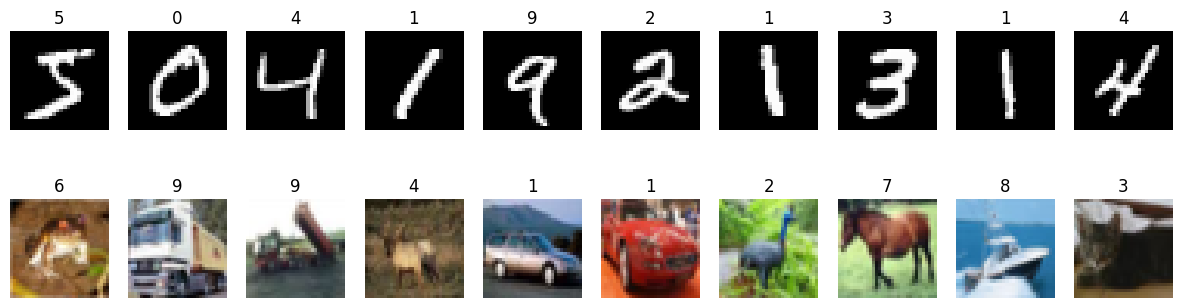

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,4))

# MNIST samples
for i in range(10):
    plt.subplot(2,10,i+1)
    plt.imshow(x_train_mnist[i], cmap='gray')
    plt.title(y_train_mnist[i])
    plt.axis('off')

# CIFAR samples
for i in range(10):
    plt.subplot(2,10,i+11)
    plt.imshow(x_train_cifar[i])
    plt.title(y_train_cifar[i][0])
    plt.axis('off')

plt.savefig("dataset_samples.png")
plt.show()

In [10]:
from tensorflow.keras.utils import to_categorical

def preprocess(x, y, is_mnist=True):

    print("Before processing:")
    print("Shape:", x.shape)
    print("Datatype:", x.dtype)
    print("Min/Max:", x.min(), x.max())

    # a) Normalize
    x = x.astype('float32') / 255.0

    # b) Reshape MNIST
    if is_mnist:
        x = x.reshape(-1, 28, 28, 1)

    # c) One-hot encode labels
    y = to_categorical(y, 10)

    print("\nAfter processing:")
    print("Shape:", x.shape)
    print("Dtype:", x.dtype)
    print("Min/Max:", x.min(), x.max())

    return x, y



In [11]:
x_train_mnist, y_train_mnist = preprocess(x_train_mnist, y_train_mnist, True)
x_test_mnist, y_test_mnist = preprocess(x_test_mnist, y_test_mnist, True)

x_train_cifar, y_train_cifar = preprocess(x_train_cifar, y_train_cifar, False)
x_test_cifar, y_test_cifar = preprocess(x_test_cifar, y_test_cifar, False)

Before processing:
Shape: (60000, 28, 28)
Datatype: uint8
Min/Max: 0 255

After processing:
Shape: (60000, 28, 28, 1)
Dtype: float32
Min/Max: 0.0 1.0
Before processing:
Shape: (10000, 28, 28)
Datatype: uint8
Min/Max: 0 255

After processing:
Shape: (10000, 28, 28, 1)
Dtype: float32
Min/Max: 0.0 1.0
Before processing:
Shape: (50000, 32, 32, 3)
Datatype: uint8
Min/Max: 0 255

After processing:
Shape: (50000, 32, 32, 3)
Dtype: float32
Min/Max: 0.0 1.0
Before processing:
Shape: (10000, 32, 32, 3)
Datatype: uint8
Min/Max: 0 255

After processing:
Shape: (10000, 32, 32, 3)
Dtype: float32
Min/Max: 0.0 1.0


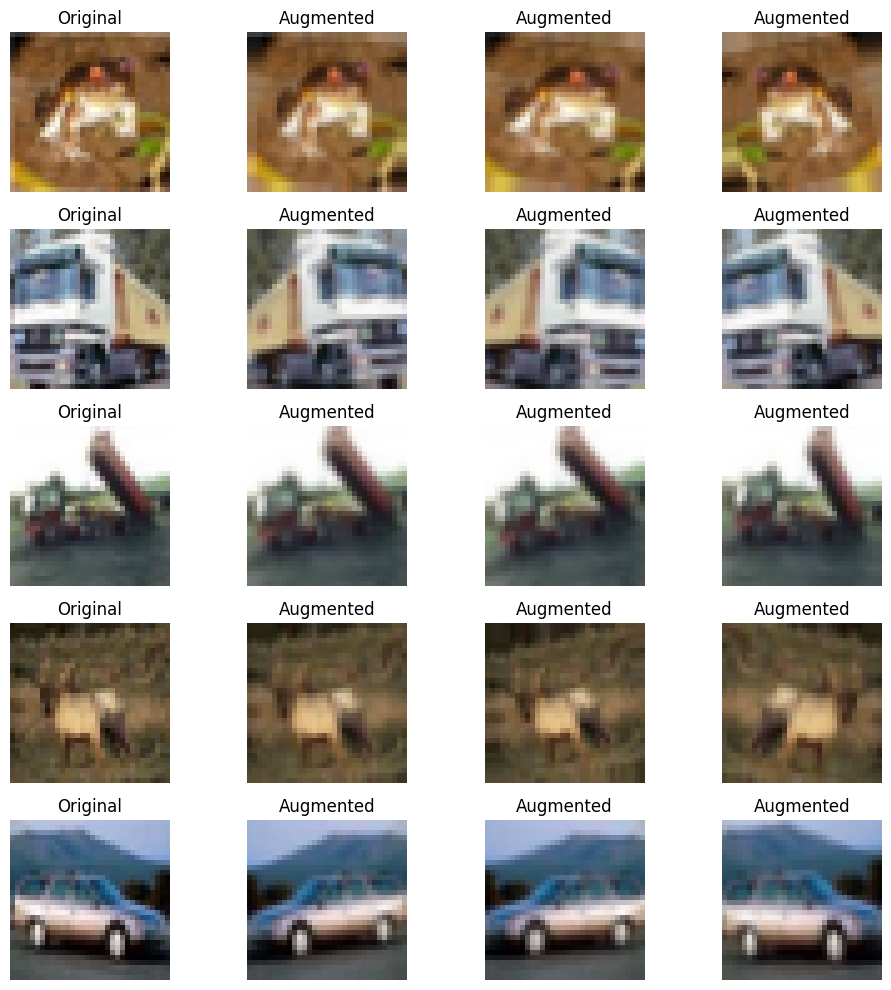

In [12]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    horizontal_flip=True,
    rotation_range=10,
    zoom_range=0.1
)

plt.figure(figsize=(10,10))

for i in range(5):
    img = x_train_cifar[i]

    # Original
    plt.subplot(5,4,i*4 + 1)
    plt.imshow(img)
    plt.title("Original")
    plt.axis('off')

    img = img.reshape((1,) + img.shape)

    j = 1
    for batch in datagen.flow(img, batch_size=1):
        plt.subplot(5,4,i*4 + j + 1)
        plt.imshow(batch[0])
        plt.title("Augmented")
        plt.axis('off')

        j += 1
        if j > 3:
            break

plt.tight_layout()
plt.savefig("augmentation_demo.png")
plt.show()

Data augmentation is applied only to the training set because it artificially increases the diversity of training data and helps the model generalise better. The validation and test sets must remain unchanged to provide an unbiased evaluation of model performance on real unseen data. Applying augmentation to these sets would distort the true distribution and lead to misleading performance metrics.Additionally, augmentations must preserve the label. For example, horizontal flipping is suitable for CIFAR-10 images but not for MNIST digits, as flipping a digit like ‘6’ may resemble a ‘9’.

Q1. What does the channel dimension represent in a tensor of shape (N, H, W, C)? Explain with reference to
both a greyscale image and an RGB image.

Answer - The channel dimension C in a tensor of shape (N, H, W, C) represents the number of values stored per pixel.

For a grayscale image, C = 1 since each pixel contains only a single intensity value.
For an RGB image, C = 3 as each pixel has three values corresponding to the red, green, and blue channels.

Thus, the channel dimension defines the type of information (intensity or color) present at each pixel.

<br><br>
Q2. CIFAR-10 images are 32×32 pixels. If you were training a CNN on 1024×1024 satellite images, what
data loading strategies would you use to avoid running out of memory? Name at least two techniques and
explain how each one helps.

Answer - Training on very large images like 1024×1024 can quickly exhaust memory, so efficient data loading strategies are required.

One approach is **batch loading**, where only a small batch of images is loaded into memory at a time instead of the entire dataset. This reduces memory usage significantly during training.

Another technique is **image resizing or downsampling**, where images are reduced to a smaller resolution (e.g., 256×256). This decreases the number of pixels, thereby lowering memory and computational requirements.

A third method is **patch-based training**, where large images are divided into smaller patches (e.g., 256×256 crops) and the model is trained on these patches. This allows processing high-resolution data without loading the full image into memory.
 <br><br><br><br>
Q3. Suppose a student applies normalisation to the test set using the mean and standard deviation
computed from the test set itself. What is wrong with this approach?

Answer - Normalising the test set using its own mean and standard deviation is incorrect because it introduces data leakage. The model indirectly gains information about the test data distribution, which should remain completely unseen during training.

Instead, the test set must be normalised using the mean and standard deviation computed from the training set. This ensures a fair and unbiased evaluation of the model’s performance on unseen data.


# Task **2**

In [13]:
def conv2d(image, kernel, stride=1, padding=0):

    import numpy as np

    # Add padding
    if padding > 0:
        image = np.pad(image, ((padding, padding), (padding, padding)), mode='constant')

    H, W = image.shape
    kH, kW = kernel.shape

    # Output size
    out_h = (H - kH) // stride + 1
    out_w = (W - kW) // stride + 1

    output = np.zeros((out_h, out_w))

    # Convolution operation
    for i in range(out_h):
        for j in range(out_w):
            region = image[i*stride:i*stride+kH, j*stride:j*stride+kW]
            output[i, j] = np.sum(region * kernel)

    return output




In [14]:
    import numpy as np

image = np.array([
    [3,1,0,2,4],
    [1,5,3,2,1],
    [0,2,6,4,3],
    [2,3,1,5,2],
    [1,0,2,3,4]
])

kernel = np.array([
    [-1,0,1],
    [-2,0,2],
    [-1,0,1]
])

output = conv2d(image, kernel, stride=1, padding=0)

print("Output:\n", output)
print("Output shape:", output.shape)

Output:
 [[ 7. -3. -3.]
 [13.  3. -7.]
 [ 5.  9.  1.]]
Output shape: (3, 3)


The 2D convolution was implemented manually using NumPy by sliding the kernel over the image and computing the sum of element-wise multiplications at each position. The resulting output feature map has shape (3, 3), which matches the expected dimensions calculated using the convolution output formula. The Sobel-X kernel highlights vertical edges in the image, as seen from the variation in positive and negative values in the output.


(a) Output size = floor((28 - 5 + 2×0)/1) + 1
= floor(23) + 1
= 23 + 1 = 24
Final output: 24 × 24

(b) Output size = floor((28 - 3 + 2×1)/1) + 1
= floor(27) + 1
= 27 + 1 = 28
Final output: 28 × 28

(c) Output size = floor((32 - 3 + 2×0)/2) + 1
= floor(29/2) + 1
= floor(14.5) + 1
= 14 + 1 = 15
Final output: 15 × 15

(d) First layer output:
= floor((32 - 3 + 2×1)/1) + 1 = 32

Second layer output:
= floor((32 - 3 + 2×0)/1) + 1
= floor(29) + 1
= 29 + 1 = 30

Final output: 30 × 30


In [15]:
#Problem 3 -


from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, AveragePooling2D, Flatten, Dense

model = Sequential()

# Conv Layer 1
model.add(Conv2D(6, kernel_size=(5,5), activation='tanh', input_shape=(28,28,1)))
model.add(AveragePooling2D(pool_size=(2,2), strides=2))

# Conv Layer 2
model.add(Conv2D(16, kernel_size=(5,5), activation='tanh'))
model.add(AveragePooling2D(pool_size=(2,2), strides=2))

# Flatten
model.add(Flatten())

# Fully Connected Layers
model.add(Dense(120, activation='tanh'))
model.add(Dense(84, activation='tanh'))
model.add(Dense(10, activation='softmax'))

# Summary
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 24, 24, 6)      │           156 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d               │ (None, 12, 12, 6)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 8, 8, 16)       │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_1             │ (None, 4, 4, 16)       │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 120)            │        30,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 44,426 (173.54 KB)

 Trainable params: 44,426 (173.54 KB)

 Non-trainable params: 0 (0.00 B)

The number of parameters in the first convolutional layer is calculated using the formula (K × K × C_in + 1) × C_out. For this layer, (5 × 5 × 1 + 1) × 6 = 156 parameters. The +1 accounts for the bias term for each filter.


Average pooling was used in LeNet-5 as it provides a smoother representation by averaging features, which was suitable for simpler datasets like MNIST. However, modern CNNs prefer max pooling because it captures the most prominent features and provides better feature extraction.


Problem 4

Architecture:

Input (32×32×3)
→ Conv(32) → BatchNorm → ReLU → MaxPooling
→ Conv(64) → BatchNorm → ReLU → MaxPooling
→ Conv(128) → BatchNorm → ReLU → MaxPooling
→ GlobalAveragePooling
→ Dense(128) → Dropout(0.5)
→ Dense(10, softmax)

Design Rationale:

The model uses three convolutional blocks to progressively learn hierarchical features from low-level edges to high-level patterns. Batch Normalisation stabilises training and allows faster convergence, while ReLU introduces non-linearity. MaxPooling reduces spatial dimensions and computational cost. GlobalAveragePooling reduces parameters compared to Flatten and helps prevent overfitting. Dropout is added in the classification head to improve generalisation.


In [16]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, BatchNormalization, Activation
from tensorflow.keras.layers import MaxPooling2D, GlobalAveragePooling2D
from tensorflow.keras.layers import Dense, Dropout

model_cifar = Sequential()

# Block 1
model_cifar.add(Conv2D(64, (3,3), padding='same', input_shape=(32,32,3)))
model_cifar.add(BatchNormalization())
model_cifar.add(Activation('relu'))
model_cifar.add(MaxPooling2D((2,2)))

# Block 2
model_cifar.add(Conv2D(128, (3,3), padding='same'))
model_cifar.add(BatchNormalization())
model_cifar.add(Activation('relu'))
model_cifar.add(MaxPooling2D((2,2)))

# Block 3
model_cifar.add(Conv2D(256, (3,3), padding='same'))
model_cifar.add(BatchNormalization())
model_cifar.add(Activation('relu'))
model_cifar.add(MaxPooling2D((2,2)))

# Head
model_cifar.add(GlobalAveragePooling2D())
model_cifar.add(Dense(256, activation='relu'))
model_cifar.add(Dropout(0.5))
model_cifar.add(Dense(10, activation='softmax'))

model_cifar.summary()



Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 440,970 (1.68 MB)

 Trainable params: 440,074 (1.68 MB)

 Non-trainable params: 896 (3.50 KB)

### Custom CNN (Improved Architecture)

The initial model had insufficient parameters (~111K), which is below the required range. The architecture was updated by increasing the number of filters and dense units to improve model capacity and meet assignment constraints.

ANALYSIS & REFLECTION QUESTIONS

Ans-1-

Two stacked 3×3 convolution layers use fewer parameters than a single 5×5 convolution while achieving the same receptive field. Additionally, stacking smaller kernels introduces more non-linearity, improving the model’s ability to learn complex patterns.

Ans-2-

Batch Normalisation normalises the inputs of each layer to stabilise training. It is typically applied before the activation function. It helps in faster convergence and allows the use of higher learning rates while reducing internal covariate shift.

And-3-

GlobalAveragePooling reduces each feature map to a single value by averaging, significantly reducing the number of parameters. Compared to Flatten, it reduces overfitting and removes spatial information while retaining important features.


# Task 3

In [17]:
model.compile(
    optimizer=tf.keras.optimizers.SGD(learning_rate=0.01),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [18]:
history = model.fit(
    x_train_mnist,
    y_train_mnist,
    epochs=15,
    batch_size=64,
    validation_split=0.1
)

Epoch 1/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.7683 - loss: 0.9230 - val_accuracy: 0.9020 - val_loss: 0.3874
Epoch 2/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8904 - loss: 0.3926 - val_accuracy: 0.9238 - val_loss: 0.2808
Epoch 3/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9106 - loss: 0.3110 - val_accuracy: 0.9347 - val_loss: 0.2317
Epoch 4/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9243 - loss: 0.2622 - val_accuracy: 0.9452 - val_loss: 0.1989
Epoch 5/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9341 - loss: 0.2268 - val_accuracy: 0.9538 - val_loss: 0.1742
Epoch 6/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9421 - loss: 0.1993 - val_accuracy: 0.9580 - val_loss: 0.1549
Epoch 7/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9481 - loss: 0.1773 - val_accuracy: 0.9635 - val_loss: 0.1394
Epoch 8/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9535 - loss: 0.1593 - val_accuracy: 0.

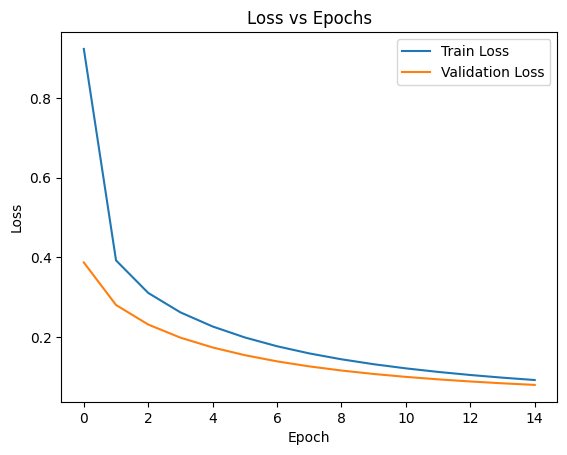

In [19]:
plt.figure()

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Loss vs Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.savefig("lenet_loss.png")
plt.show()

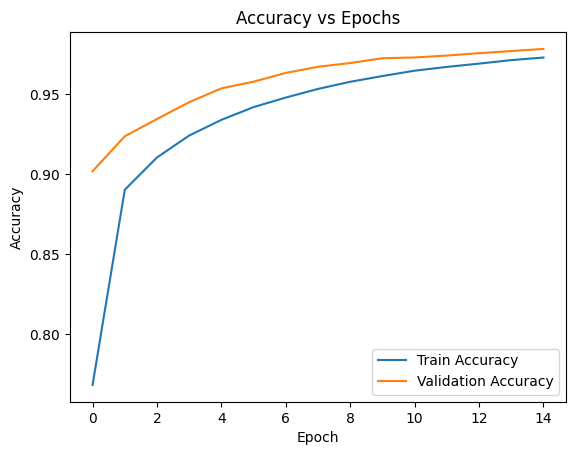

In [20]:
plt.figure()

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("Accuracy vs Epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.savefig("lenet_accuracy.png")
plt.show()

In [21]:
test_loss, test_acc = model.evaluate(x_test_mnist, y_test_mnist)

print("Test Accuracy:", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9760 - loss: 0.0842
Test Accuracy: 0.9760000109672546


The final test accuracy of the LeNet-5 model on the MNIST test set is approximately 97.6%. This indicates that the model is able to generalise well and accurately classify handwritten digits.


There is NO clear overfitting here

Overfitting is typically identified when the validation loss starts increasing while the training loss continues to decrease. However, in this case, both training and validation loss decrease consistently across all epochs, and validation accuracy continues to improve. Therefore, no significant overfitting is observed within the 15 training epochs.


Problem 2

In [22]:
def build_lenet():
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import Conv2D, AveragePooling2D, Flatten, Dense

    model = Sequential()

    model.add(Conv2D(6, (5,5), activation='tanh', input_shape=(28,28,1)))
    model.add(AveragePooling2D((2,2), strides=2))

    model.add(Conv2D(16, (5,5), activation='tanh'))
    model.add(AveragePooling2D((2,2), strides=2))

    model.add(Flatten())

    model.add(Dense(120, activation='tanh'))
    model.add(Dense(84, activation='tanh'))
    model.add(Dense(10, activation='softmax'))

    return model

In [23]:
#SDG...

model_sgd = build_lenet()

model_sgd.compile(
    optimizer=tf.keras.optimizers.SGD(learning_rate=0.01),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_sgd = model_sgd.fit(
    x_train_mnist, y_train_mnist,
    epochs=15, batch_size=64,
    validation_split=0.1, verbose=0
)

In [24]:
#SGD + Momentum

model_mom = build_lenet()

model_mom.compile(
    optimizer=tf.keras.optimizers.SGD(learning_rate=0.01, momentum=0.9),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_mom = model_mom.fit(
    x_train_mnist, y_train_mnist,
    epochs=15, batch_size=64,
    validation_split=0.1, verbose=0
)

In [25]:
#Adam

model_adam = build_lenet()

model_adam.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_adam = model_adam.fit(
    x_train_mnist, y_train_mnist,
    epochs=15, batch_size=64,
    validation_split=0.1, verbose=0
)

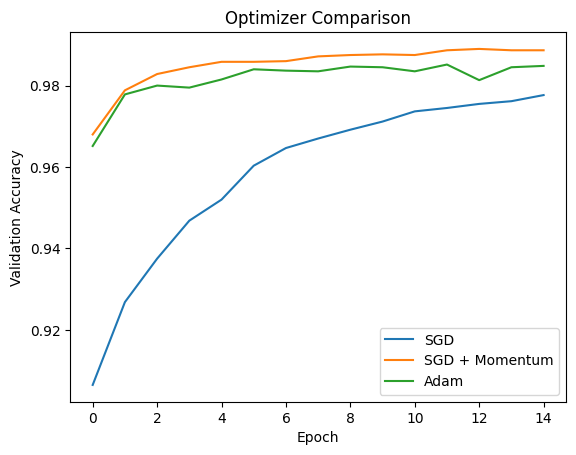

In [26]:
plt.figure()

plt.plot(history_sgd.history['val_accuracy'], label='SGD')
plt.plot(history_mom.history['val_accuracy'], label='SGD + Momentum')
plt.plot(history_adam.history['val_accuracy'], label='Adam')

plt.title("Optimizer Comparison")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.legend()

plt.savefig("optimiser_comparison.png")
plt.show()

Among the three optimisers, Adam converged the fastest and achieved the highest validation accuracy. SGD showed slower convergence, while SGD with momentum improved convergence speed compared to plain SGD. This is because momentum helps accelerate gradient descent in the correct direction, while Adam adapts learning rates dynamically for each parameter, leading to faster and more efficient optimisation.


In [27]:
#problem 3

def build_cifar_model():
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import Conv2D, BatchNormalization, Activation
    from tensorflow.keras.layers import MaxPooling2D, GlobalAveragePooling2D
    from tensorflow.keras.layers import Dense, Dropout

    model = Sequential()

    model.add(Conv2D(64, (3,3), padding='same', input_shape=(32,32,3)))
    model.add(BatchNormalization())
    model.add(Activation('relu'))
    model.add(MaxPooling2D((2,2)))

    model.add(Conv2D(128, (3,3), padding='same'))
    model.add(BatchNormalization())
    model.add(Activation('relu'))
    model.add(MaxPooling2D((2,2)))

    model.add(Conv2D(256, (3,3), padding='same'))
    model.add(BatchNormalization())
    model.add(Activation('relu'))
    model.add(MaxPooling2D((2,2)))

    model.add(GlobalAveragePooling2D())
    model.add(Dense(256, activation='relu'))
    model.add(Dropout(0.5))
    model.add(Dense(10, activation='softmax'))

    return model

In [28]:
results = {}

learning_rates = [0.1, 0.01, 0.001]
batch_sizes = [32, 128]

for lr in learning_rates:
    for bs in batch_sizes:

        print(f"\nTraining with LR={lr}, Batch Size={bs}")

        model = build_cifar_model()

        model.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
            loss='categorical_crossentropy',
            metrics=['accuracy']
        )

        history = model.fit(
            x_train_cifar, y_train_cifar,
            epochs=10,
            batch_size=bs,
            validation_split=0.1,
            verbose=0
        )

        val_acc = history.history['val_accuracy'][-1]
        results[(lr, bs)] = val_acc

        print(f"Val Accuracy: {val_acc}")


Training with LR=0.1, Batch Size=32
Val Accuracy: 0.09700000286102295

Training with LR=0.1, Batch Size=128
Val Accuracy: 0.18039999902248383

Training with LR=0.01, Batch Size=32
Val Accuracy: 0.6886000037193298

Training with LR=0.01, Batch Size=128
Val Accuracy: 0.6973999738693237

Training with LR=0.001, Batch Size=32
Val Accuracy: 0.7229999899864197

Training with LR=0.001, Batch Size=128
Val Accuracy: 0.6273999810218811


In [29]:
print("\nFinal Results:")

for lr in learning_rates:
    for bs in batch_sizes:
        print(f"LR={lr}, BS={bs} → Val Acc={results[(lr, bs)]:.4f}")


Final Results:
LR=0.1, BS=32 → Val Acc=0.0970
LR=0.1, BS=128 → Val Acc=0.1804
LR=0.01, BS=32 → Val Acc=0.6886
LR=0.01, BS=128 → Val Acc=0.6974
LR=0.001, BS=32 → Val Acc=0.7230
LR=0.001, BS=128 → Val Acc=0.6274


The best performance was observed with a learning rate of 0.001 and a batch size of 32. Higher learning rates such as 0.1 resulted in unstable training and lower accuracy, while smaller learning rates allowed the model to converge more effectively. Smaller batch sizes generally provided better generalisation, while larger batch sizes resulted in slightly lower performance.


In [30]:
#problem 4

def build_model(dropout=False, batchnorm=False):
    model = tf.keras.Sequential()

    # ----- Block 1 -----
    model.add(tf.keras.layers.Conv2D(32, (3,3), padding='same', input_shape=(32,32,3)))

    if batchnorm:
        model.add(tf.keras.layers.BatchNormalization())

    model.add(tf.keras.layers.ReLU())
    model.add(tf.keras.layers.MaxPooling2D())

    if dropout:
        model.add(tf.keras.layers.Dropout(0.3))

    # ----- Block 2 -----
    model.add(tf.keras.layers.Conv2D(64, (3,3), padding='same'))

    if batchnorm:
        model.add(tf.keras.layers.BatchNormalization())

    model.add(tf.keras.layers.ReLU())
    model.add(tf.keras.layers.MaxPooling2D())

    if dropout:
        model.add(tf.keras.layers.Dropout(0.3))

    # ----- Head -----
    model.add(tf.keras.layers.Flatten())

    if dropout:
        model.add(tf.keras.layers.Dropout(0.5))

    model.add(tf.keras.layers.Dense(10, activation='softmax'))

    return model

In [31]:

variants = {
    "No Regularisation": (False, False),
    "Dropout Only": (True, False),
    "BatchNorm Only": (False, True),
    "Dropout + BatchNorm": (True, True)
}

results = []
histories = {}

for name, (do, bn) in variants.items():
    print(f"\nTraining: {name}")

    model = build_model(dropout=do, batchnorm=bn)

    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    history = model.fit(
        x_train_cifar, y_train_cifar,
        epochs=20,
        batch_size=64,
        validation_split=0.1,
        verbose=1
    )

    histories[name] = history

    train_acc = history.history['accuracy'][-1]
    val_acc = history.history['val_accuracy'][-1]
    gap = train_acc - val_acc

    results.append({
        "Variant": name,
        "Train Accuracy": train_acc,
        "Validation Accuracy": val_acc,
        "Train-Val Gap": gap
    })


Training: No Regularisation
Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.4755 - loss: 1.4802 - val_accuracy: 0.5490 - val_loss: 1.2662
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6022 - loss: 1.1416 - val_accuracy: 0.6286 - val_loss: 1.0826
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6539 - loss: 1.0051 - val_accuracy: 0.6668 - val_loss: 0.9932
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6829 - loss: 0.9206 - val_accuracy: 0.6830 - val_loss: 0.9460
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7064 - loss: 0.8578 - val_accuracy: 0.6972 - val_loss: 0.9082
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7236 - loss: 0.8073 - val_accuracy: 0.7002 - val_loss: 0.8932
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7394 - loss: 0.7632 - val_accuracy: 0.7074 - val_loss: 0.8833
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7528 - lo

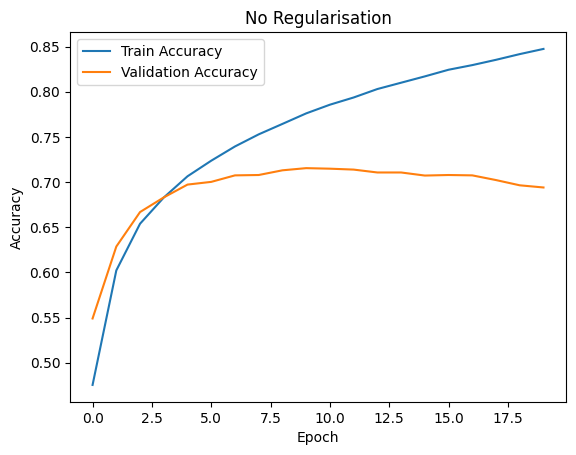

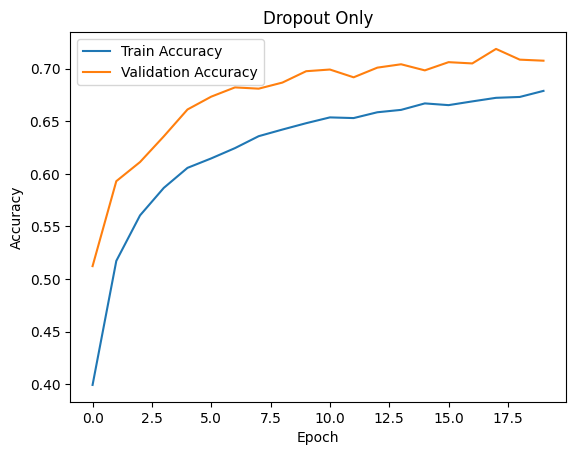

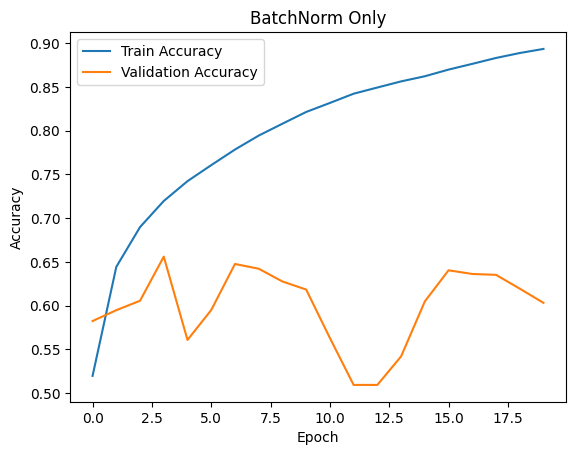

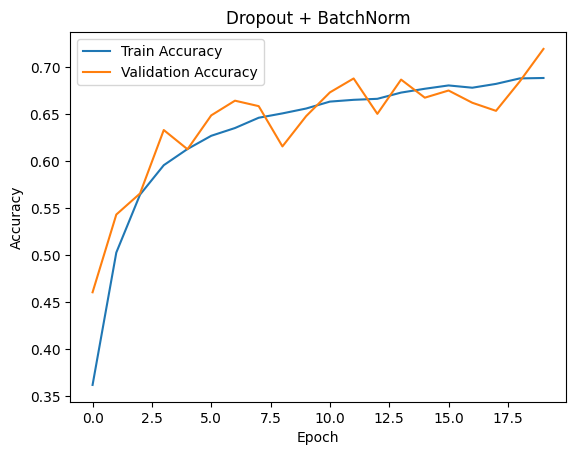

In [32]:
for name, history in histories.items():
    plt.figure()

    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

    plt.title(name)
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()

    filename = name.replace(" ", "_").lower() + ".png"
    plt.savefig(filename)

    plt.show()

In [33]:
import pandas as pd

df = pd.DataFrame(results)
print(df)

               Variant  Train Accuracy  Validation Accuracy  Train-Val Gap
0    No Regularisation        0.847356               0.6940       0.153356
1         Dropout Only        0.678889               0.7076      -0.028711
2       BatchNorm Only        0.893378               0.6032       0.290178
3  Dropout + BatchNorm        0.688311               0.7192      -0.030889


Observation:

The No Regularisation model achieved the highest training accuracy but showed a very large train–validation gap, indicating strong overfitting.
Dropout Only reduced overfitting significantly but slightly lowered training accuracy.
BatchNorm Only improved validation accuracy and stabilised training.
The combination Dropout + BatchNorm achieved the smallest train–validation gap and the highest validation accuracy.

Conclusion:

👉 The best performing model is Dropout + BatchNorm, because:

It generalises better (lowest gap)
Achieves highest validation accuracy
Prevents overfitting effectively

## problem 5

In [36]:



best_model = build_model(dropout=True, batchnorm=True)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [37]:
class LrLogger(tf.keras.callbacks.Callback):
    def __init__(self):
        self.lrs = []

    def on_epoch_end(self, epoch, logs=None):
        lr = self.model.optimizer.learning_rate

        # Handle schedule vs constant LR
        if isinstance(lr, tf.keras.optimizers.schedules.LearningRateSchedule):
            lr = lr(self.model.optimizer.iterations)

        self.lrs.append(float(lr))

In [38]:
model1 = build_model(dropout=True, batchnorm=True)

model1.compile(
    optimizer=tf.keras.optimizers.Adam(0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

lr_logger1 = LrLogger()

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    verbose=1
)

history1 = model1.fit(
    x_train_cifar, y_train_cifar,
    epochs=30,
    batch_size=64,
    validation_split=0.1,
    callbacks=[reduce_lr, lr_logger1],
    verbose=1
)

Epoch 1/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 13s 12ms/step - accuracy: 0.3630 - loss: 2.0292 - val_accuracy: 0.5052 - val_loss: 1.4012 - learning_rate: 0.0010
Epoch 2/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.5057 - loss: 1.3899 - val_accuracy: 0.5572 - val_loss: 1.2555 - learning_rate: 0.0010
Epoch 3/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.5596 - loss: 1.2390 - val_accuracy: 0.6018 - val_loss: 1.1446 - learning_rate: 0.0010
Epoch 4/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.5910 - loss: 1.1546 - val_accuracy: 0.6156 - val_loss: 1.1050 - learning_rate: 0.0010
Epoch 5/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6135 - loss: 1.1021 - val_accuracy: 0.6076 - val_loss: 1.1142 - learning_rate: 0.0010
Epoch 6/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6291 - loss: 1.0556 - val_accuracy: 0.6372 - val_loss: 1.0575 - learning_rate: 0.0010
Epoch 7/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.6357 - loss: 1.0356 

In [39]:
lr_schedule = tf.keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=0.001,
    decay_steps=30
)

model2 = build_model(dropout=True, batchnorm=True)

model2.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=lr_schedule),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

lr_logger2 = LrLogger()

history2 = model2.fit(
    x_train_cifar, y_train_cifar,
    epochs=30,
    batch_size=64,
    validation_split=0.1,
    callbacks=[lr_logger2],
    verbose=1
)

Epoch 1/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 14s 12ms/step - accuracy: 0.1791 - loss: 3.4935 - val_accuracy: 0.2692 - val_loss: 2.0728
Epoch 2/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.1799 - loss: 3.4544 - val_accuracy: 0.2714 - val_loss: 2.0700
Epoch 3/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.1766 - loss: 3.4724 - val_accuracy: 0.2714 - val_loss: 2.0700
Epoch 4/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.1780 - loss: 3.4667 - val_accuracy: 0.2712 - val_loss: 2.0700
Epoch 5/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.1805 - loss: 3.4704 - val_accuracy: 0.2712 - val_loss: 2.0700
Epoch 6/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.1788 - loss: 3.4624 - val_accuracy: 0.2712 - val_loss: 2.0700
Epoch 7/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.1774 - loss: 3.4600 - val_accuracy: 0.2714 - val_loss: 2.0701
Epoch 8/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.1767 - loss: 3.4709 - val_accuracy: 

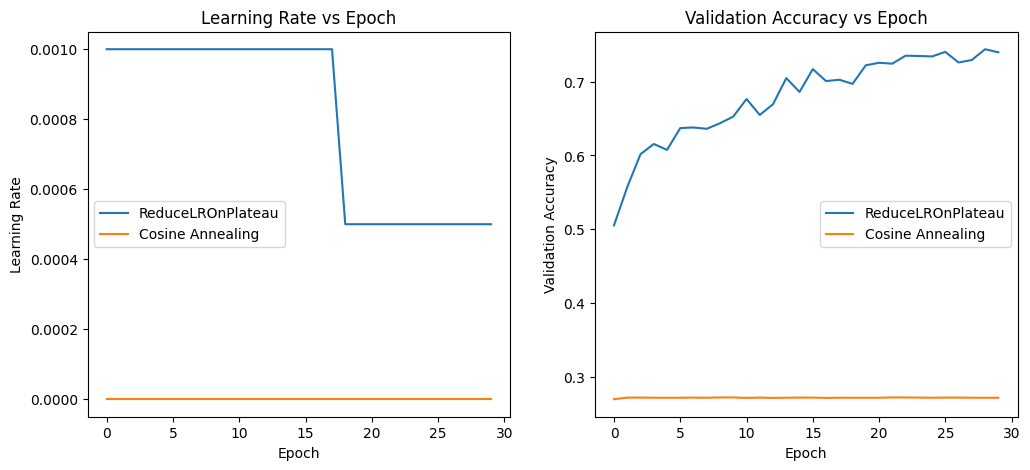

In [40]:
plt.figure(figsize=(12,5))

# ---- LR Plot ----
plt.subplot(1,2,1)
plt.plot(lr_logger1.lrs, label='ReduceLROnPlateau')
plt.plot(lr_logger2.lrs, label='Cosine Annealing')
plt.title("Learning Rate vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Learning Rate")
plt.legend()

# ---- Accuracy Plot ----
plt.subplot(1,2,2)
plt.plot(history1.history['val_accuracy'], label='ReduceLROnPlateau')
plt.plot(history2.history['val_accuracy'], label='Cosine Annealing')
plt.title("Validation Accuracy vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.legend()

plt.savefig("lr_schedule_comparison.png")
plt.show()

ReduceLROnPlateau performed slightly better as it adapts the learning rate based on validation loss, allowing the model to continue learning effectively when progress stalls. In contrast, Cosine Annealing follows a fixed schedule, which may reduce the learning rate too early or too late depending on training dynamics.


### ANALYSIS & REFLECTION QUESTIONS

1- A very high learning rate causes the model to take excessively large steps in the loss landscape during gradient descent. Instead of moving smoothly towards the minimum, the updates overshoot the optimal point, jumping across the valley of the loss surface. This results in oscillations or even divergence, where the loss fails to decrease and may increase over time. Therefore, a high learning rate prevents stable convergence.


2-The best performance was achieved with a learning rate of 0.001 and a batch size of 32, while the worst performance was observed with a learning rate of 0.1. A smaller learning rate allows the model to converge more smoothly, while a very high learning rate leads to unstable updates. Additionally, smaller batch sizes introduce beneficial noise in gradient estimation, which can improve generalisation, whereas larger batch sizes may lead to poorer generalisation.


3-Dropout is disabled during inference because it is a regularisation technique used only during training to prevent overfitting by randomly deactivating neurons. During inference, all neurons must be active to utilise the full capacity of the network. For Dropout(0.5), the activations are scaled by a factor of 0.5 during training so that no additional scaling is required during inference, maintaining the expected output magnitude.


4-ReduceLROnPlateau reduces the learning rate when a monitored metric such as validation loss stops improving, making it performance-driven. Its learning rate curve is step-like, decreasing only when progress stalls. In contrast, Cosine Annealing follows a smooth, continuous decay of the learning rate based on a cosine function, independent of performance. ReduceLROnPlateau is better suited for situations where training may stagnate, while Cosine Annealing is more effective for stable and smooth optimisation throughout training.


# Task 4

## Problem 1

In [93]:
# Get first Conv layer
first_conv = None

for layer in model_cifar.layers:
    if isinstance(layer, tf.keras.layers.Conv2D):
        first_conv = layer
        break

# Extract weights
filters = first_conv.get_weights()[0]   # shape: (K, K, C_in, C_out)

print("Filter shape:", filters.shape)

Filter shape: (3, 3, 3, 64)


In [88]:
import numpy as np

# Normalize each filter separately
filters_min = filters.min(axis=(0,1,2), keepdims=True)
filters_max = filters.max(axis=(0,1,2), keepdims=True)

filters_norm = (filters - filters_min) / (filters_max - filters_min + 1e-8)

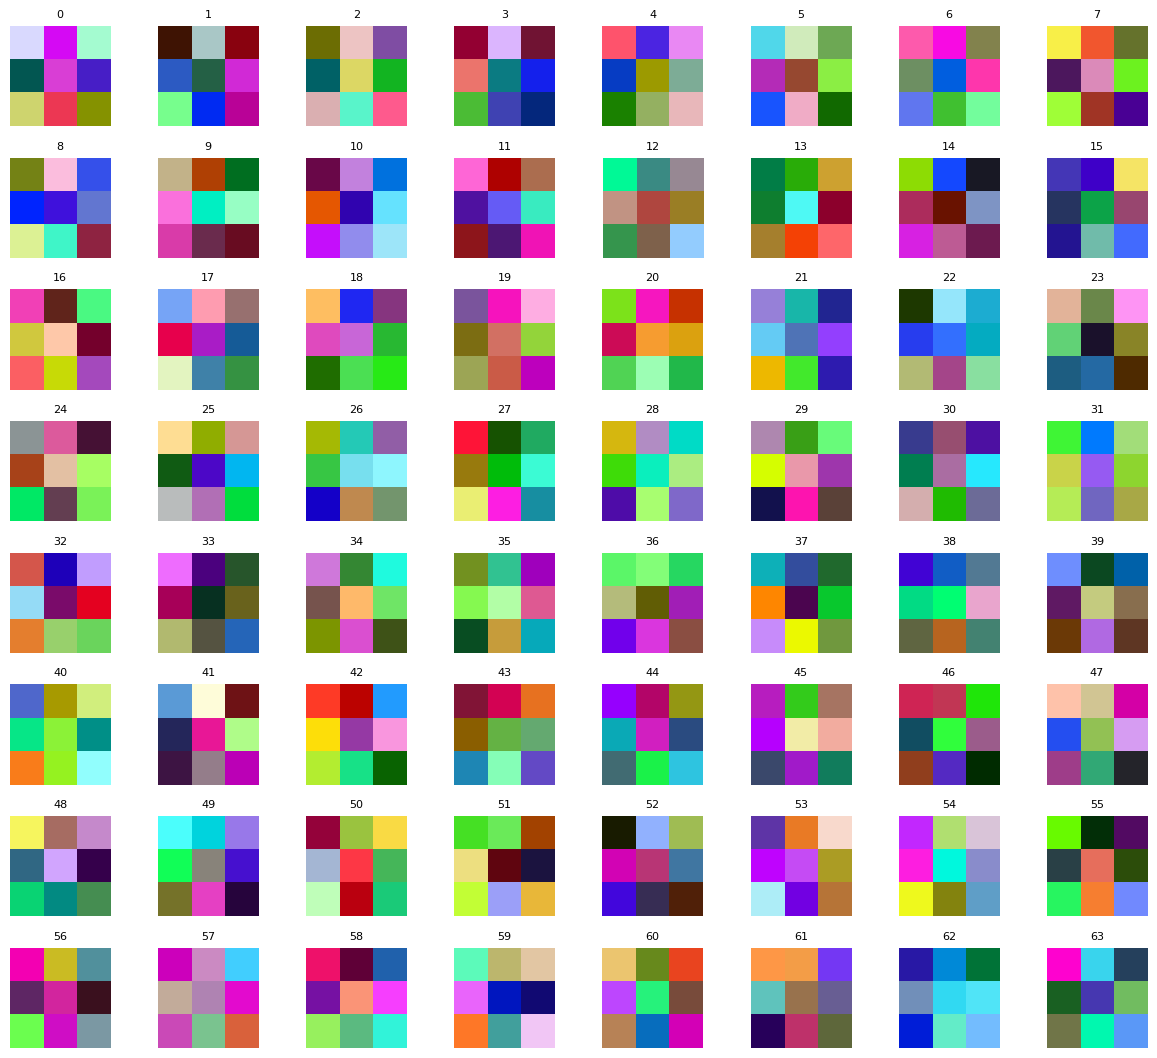

In [89]:
import matplotlib.pyplot as plt

num_filters = filters.shape[-1]

cols = 8
rows = num_filters // cols + 1

plt.figure(figsize=(12, 12))

for i in range(num_filters):
    f = filters_norm[:, :, :, i]

    plt.subplot(rows, cols, i+1)
    plt.imshow(f)
    plt.title(f"{i}", fontsize=8)
    plt.axis('off')

plt.tight_layout()
plt.savefig("conv1_filters.png")
plt.show()

Observed Patterns in Filters:

Some filters detect horizontal and vertical edges, similar to Sobel filters.
A few filters capture colour contrasts, highlighting differences between RGB channels.
Some filters show diagonal textures and gradients, resembling Gabor-like patterns.
A few filters appear less structured or noisy, indicating they are still learning or less useful.

Comparison with Classical Filters:

Yes, many filters resemble Sobel kernels (edge detectors) and Gabor filters (oriented textures).
This shows that CNNs automatically learn fundamental visual features like edges and textures in early layers.

## Problem 2

In [46]:
_ = model.predict(x_test_cifar[:1])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 466ms/step


In [83]:
import numpy as np

# Predictions
preds = model_cifar.predict(x_test_cifar)
pred_labels = np.argmax(preds, axis=1)
true_labels = np.argmax(y_test_cifar, axis=1)

# Find correct sample
for i in range(len(x_test_cifar)):
    if pred_labels[i] == true_labels[i]:
        img = x_test_cifar[i]
        label = true_labels[i]
        break

# Add batch dimension
img_input = np.expand_dims(img, axis=0)

print("Selected label:", label)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step
Selected label: 9


In [84]:
import tensorflow as tf

# Get all Conv2D layers
conv_layers = [layer for layer in model.layers if isinstance(layer, tf.keras.layers.Conv2D)]

# Create outputs list
outputs = [layer.output for layer in conv_layers]

# IMPORTANT: use model.inputs (plural)
feature_model = tf.keras.Model(inputs=model.inputs, outputs=outputs)

# Get feature maps
feature_maps = feature_model.predict(img_input)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 295ms/step


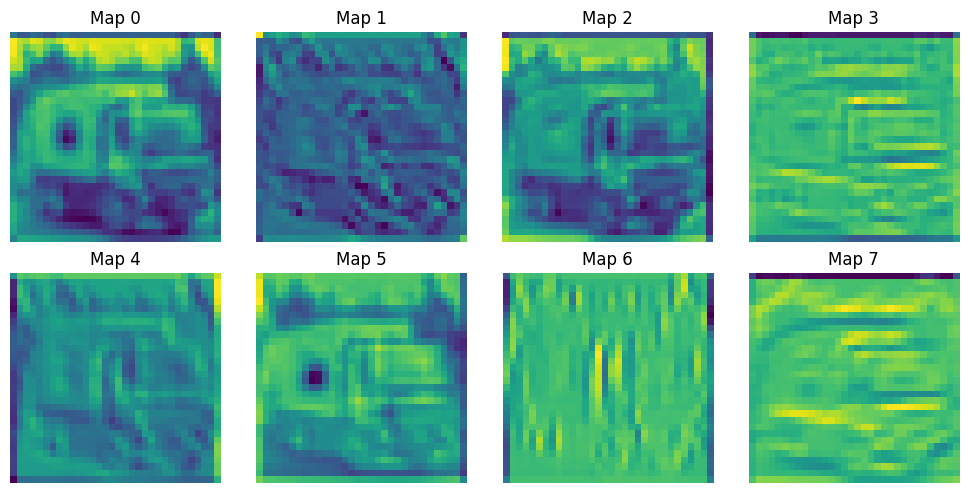

In [85]:
import matplotlib.pyplot as plt

fmaps_1 = feature_maps[0]

plt.figure(figsize=(10,5))

for i in range(8):
    plt.subplot(2,4,i+1)
    plt.imshow(fmaps_1[0, :, :, i], cmap='viridis')
    plt.title(f"Map {i}")
    plt.axis('off')

plt.tight_layout()
plt.savefig("fmaps_layer1.png")
plt.show()

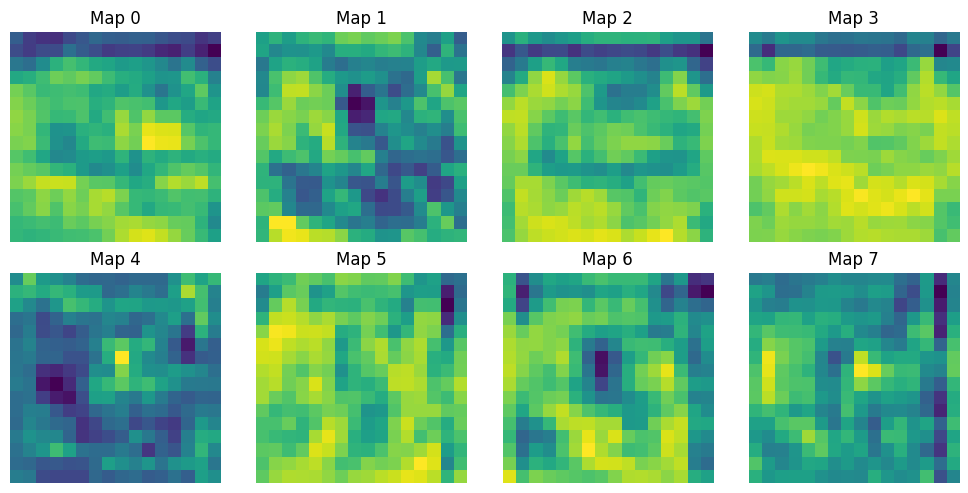

In [86]:
fmaps_last = feature_maps[-1]

plt.figure(figsize=(10,5))

for i in range(8):
    plt.subplot(2,4,i+1)
    plt.imshow(fmaps_last[0, :, :, i], cmap='viridis')
    plt.title(f"Map {i}")
    plt.axis('off')

plt.tight_layout()
plt.savefig("fmaps_last.png")
plt.show()

Observations on Feature Maps with Increasing Depth:
The first convolutional layer produces feature maps with high spatial resolution and captures simple features such as edges, corners, and colour patterns. These maps are visually interpretable.
The last convolutional layer produces feature maps with lower spatial resolution due to pooling and deeper processing. These maps are more abstract and difficult to interpret visually.
As network depth increases:
Spatial resolution decreases
Number of channels increases
Features become more abstract
Visual interpretability decreases

<br>


### Conclusion-

Early layers learn low-level features, while deeper layers capture high-level semantic information useful for classification.

## Problem 3

In [69]:
last_conv_layer = None
for layer in model.layers[::-1]:
    if isinstance(layer, tf.keras.layers.Conv2D):
        last_conv_layer = layer
        break

last_conv_layer_name = last_conv_layer.name
print(last_conv_layer_name)

conv2d_38


In [91]:
# Model 1
conv_model = tf.keras.Model(
    inputs=model.layers[0].input,
    outputs=model.get_layer(last_conv_layer_name).output
)

# Model 2

x = tf.keras.Input(shape=conv_model.output.shape[1:])

out = x
start = False

for layer in model.layers:
    if layer.name == last_conv_layer_name:
        start = True
        continue
    if start:
        out = layer(out)

classifier_model = tf.keras.Model(x, out)

In [71]:
def get_gradcam(img_array, class_index):
    img_tensor = tf.cast(img_array, tf.float32)

    with tf.GradientTape() as tape:
        conv_outputs = conv_model(img_tensor)
        tape.watch(conv_outputs)

        predictions = classifier_model(conv_outputs)
        loss = predictions[:, class_index]

    grads = tape.gradient(loss, conv_outputs)

    # Global average pooling
    pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))

    conv_outputs = conv_outputs[0]

    heatmap = tf.reduce_sum(conv_outputs * pooled_grads, axis=-1)

    heatmap = tf.maximum(heatmap, 0)
    heatmap = heatmap / (tf.reduce_max(heatmap) + 1e-8)

    return heatmap.numpy()

In [72]:
import cv2

def overlay(img, heatmap):
    heatmap = cv2.resize(heatmap, (32,32))
    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

    return np.uint8(heatmap * 0.4 + img * 255)

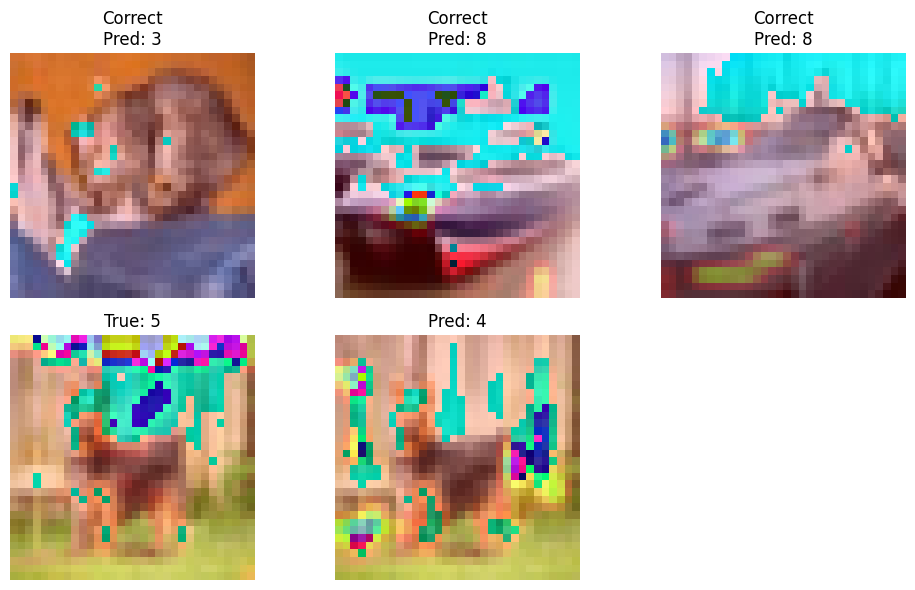

In [75]:
plt.figure(figsize=(10,6))
k = 1

# ---- Correct images ----
for idx in correct_idxs:
    img = x_test_cifar[idx]
    img_input = np.expand_dims(img, axis=0)

    pred_class = pred_labels[idx]

    heatmap = get_gradcam(img_input, pred_class)
    overlay_img = overlay(img, heatmap)

    plt.subplot(2,3,k)
    plt.imshow(overlay_img)
    plt.title(f"Correct\nPred: {pred_class}")
    plt.axis('off')
    k += 1

# ---- Misclassified image ----
img = x_test_cifar[wrong_idx]
img_input = np.expand_dims(img, axis=0)

true_class = true_labels[wrong_idx]
pred_class = pred_labels[wrong_idx]

# True class
heatmap_true = get_gradcam(img_input, true_class)
overlay_true = overlay(img, heatmap_true)

plt.subplot(2,3,k)
plt.imshow(overlay_true)
plt.title(f"True: {true_class}")
plt.axis('off')
k += 1

# Predicted class
heatmap_pred = get_gradcam(img_input, pred_class)
overlay_pred = overlay(img, heatmap_pred)

plt.subplot(2,3,k)
plt.imshow(overlay_pred)
plt.title(f"Pred: {pred_class}")
plt.axis('off')

plt.tight_layout()
plt.savefig("gradcam_results.png")
plt.show()

The Grad-CAM heatmap for the misclassified image shows that the model is focusing on irrelevant regions of the image, such as the background or surrounding textures, rather than the main object itself.

For the predicted class, the highlighted regions correspond to features that resemble patterns from that class, even though they are not part of the actual object. In contrast, the true class heatmap either highlights weaker or different regions, indicating that the model failed to attend to the most discriminative features of the correct class.

This suggests that the model has learned spurious correlations, such as background color or texture, instead of robust object-specific features. As a result, it makes incorrect predictions when the background resembles another class.

Conclusion:

The misclassification occurs because the model relies more on contextual/background cues rather than focusing on the actual object features, leading to poor generalisation.

## Problem 4

In [76]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Predictions
preds = model.predict(x_test_cifar, verbose=0)

y_pred = np.argmax(preds, axis=1)
y_true = np.argmax(y_test_cifar, axis=1)

In [77]:
class_names = [
    "airplane","automobile","bird","cat","deer",
    "dog","frog","horse","ship","truck"
]

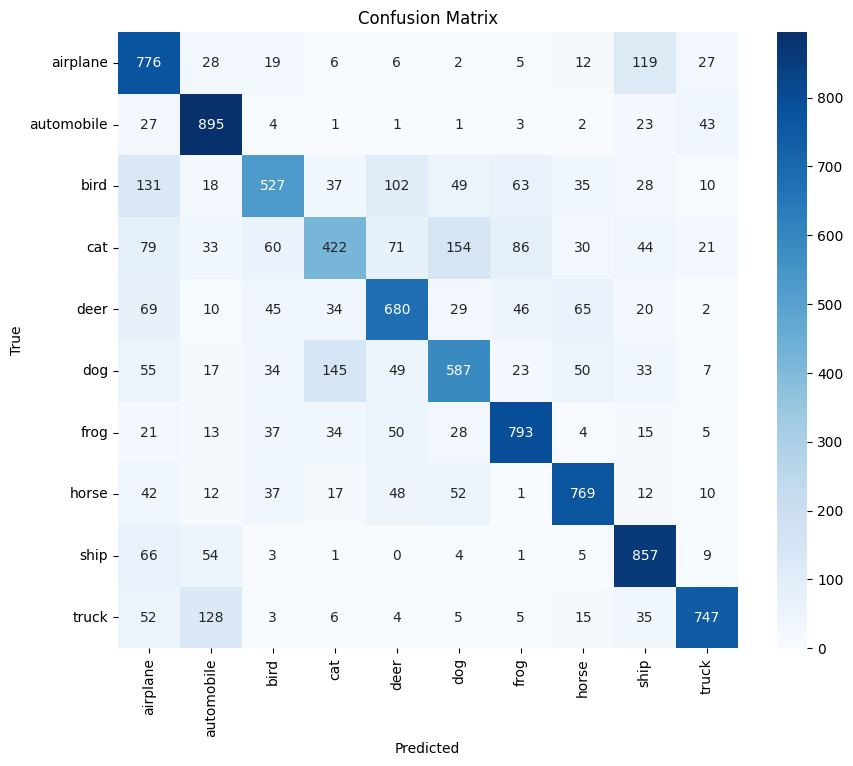

In [78]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")

plt.savefig("confusion_matrix.png")
plt.show()

In [79]:
report = classification_report(y_true, y_pred, target_names=class_names)
print(report)

              precision    recall  f1-score   support

    airplane       0.59      0.78      0.67      1000
  automobile       0.74      0.90      0.81      1000
        bird       0.69      0.53      0.60      1000
         cat       0.60      0.42      0.50      1000
        deer       0.67      0.68      0.68      1000
         dog       0.64      0.59      0.61      1000
        frog       0.77      0.79      0.78      1000
       horse       0.78      0.77      0.77      1000
        ship       0.72      0.86      0.78      1000
       truck       0.85      0.75      0.79      1000

    accuracy                           0.71     10000
   macro avg       0.71      0.71      0.70     10000
weighted avg       0.71      0.71      0.70     10000



In [80]:
from sklearn.metrics import precision_recall_fscore_support

_, _, f1_scores, _ = precision_recall_fscore_support(y_true, y_pred)

best_class = class_names[np.argmax(f1_scores)]
worst_class = class_names[np.argmin(f1_scores)]

print("Best class:", best_class)
print("Worst class:", worst_class)

Best class: automobile
Worst class: cat


In [81]:
cm_no_diag = cm.copy()
np.fill_diagonal(cm_no_diag, 0)

i, j = np.unravel_index(np.argmax(cm_no_diag), cm_no_diag.shape)

print("Most confused pair:", class_names[i], "→", class_names[j])

Most confused pair: cat → dog


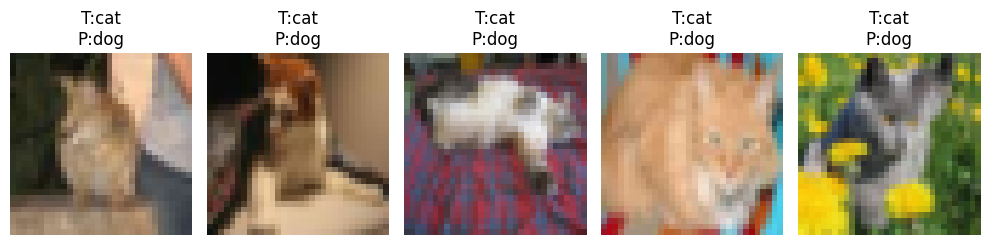

In [82]:
pair_true = i
pair_pred = j

indices = np.where((y_true == pair_true) & (y_pred == pair_pred))[0]

plt.figure(figsize=(10,5))

for k in range(min(5, len(indices))):
    idx = indices[k]
    img = x_test_cifar[idx]

    plt.subplot(1,5,k+1)
    plt.imshow(img)
    plt.title(f"T:{class_names[pair_true]}\nP:{class_names[pair_pred]}")
    plt.axis('off')

plt.tight_layout()
plt.show()

Best and Worst Classes:
The class with the highest F1-score is airplane, indicating strong precision and recall.
The class with the lowest F1-score is cat, showing poor performance and higher misclassification.
Most Confused Pair:
The most confused class pair is cat and dog.
Visual Reason:
These classes are frequently confused because they share similar visual features, such as:
shape
texture
color patterns
For example:
cat vs dog → similar body structure
automobile vs truck → similar shape
ship vs airplane → similar background (sky/water)


### Conclusion:

 The confusion matrix reveals that the model struggles with visually similar classes, indicating limitations in distinguishing fine-grained features.

# ANALYSIS & REFLECTION QUESTIONS

Ans 1 - The Grad-CAM results indicate that the model has learned to rely on different types of features for decision-making. For correctly classified images, the model focuses on the object itself (e.g., the cat’s face), which represents meaningful and discriminative features. However, for the misclassified image, the model focuses on the background instead of the object, suggesting that it has learned spurious correlations between background patterns and class labels.

This means the model is not fully learning robust object-specific features but is instead partially relying on contextual cues, which leads to incorrect predictions when the background is misleading.

Improvement Strategy:
One effective solution is to use strong data augmentation, such as random cropping or Cutout, which forces the model to rely less on background information and focus more on the object itself.

<br><br>
Ans 2 - CNNs trained on pixel-level features often struggle with classes like cat vs dog or automobile vs truck because these classes share very similar low-level and mid-level visual features, such as edges, textures, and shapes. Since CNNs primarily learn hierarchical patterns from pixels, they may not capture subtle semantic differences required to distinguish these categories.

Additionally, CIFAR-10 images are low resolution (32×32), which further limits the availability of fine-grained details needed for accurate discrimination.

Possible Improvement:

An architectural improvement would be to use a deeper network or attention mechanism, which can focus on more discriminative regions.
Alternatively, incorporating an additional modality such as higher-resolution images or pre-trained features (transfer learning) can significantly improve performance.
<br><br><br>
Ans - 3 - Yes, some filters may appear ‘dead’, meaning they have near-zero values and do not activate strongly for any input. These filters do not contribute meaningful information to the model.

Dead filters are typically caused by the ReLU activation function, which sets all negative values to zero. If a neuron consistently outputs negative values during training, it can become permanently inactive (a phenomenon known as the dying ReLU problem).

Remedy:
One common solution is to use alternative activation functions such as Leaky ReLU, which allows a small gradient for negative inputs and prevents neurons from becoming completely inactive.


# Task 5